# RLMPC / Gnu-RL Results

Clean analysis notebook for **Gnu-RL style RLMPC with offline DiffMPC imitation and online cost optimization**.

This notebook mirrors `02_mpc_results.ipynb`: it loads saved rollouts, plots February comfort, and displays CityLearn KPIs. It should not define controller classes.

## 1. Experiment Configuration

In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.scenarios import SCENARIOS

RESULTS = Path('../results')
CONTROLLER = 'rlmpc'
SCENARIOS


{'no_occupant': ScenarioConfig(name='no_occupant', occupant_enabled=False, dynamic_comfort_enabled=False, peak_flattening_enabled=False, peak_weight=0.0),
 'occupant_present': ScenarioConfig(name='occupant_present', occupant_enabled=True, dynamic_comfort_enabled=True, peak_flattening_enabled=False, peak_weight=0.0),
 'occupant_present_peak_flattening': ScenarioConfig(name='occupant_present_peak_flattening', occupant_enabled=True, dynamic_comfort_enabled=True, peak_flattening_enabled=True, peak_weight=0.1)}

## 2. Offline Imitation Checkpoint

In [7]:
offline_checkpoint = RESULTS / 'models' / CONTROLLER / 'offline' / 'rlmpc__no_occupant.pt'
offline_bundle = RESULTS / 'models' / CONTROLLER / 'bundles' / 'rlmpc__no_occupant.json'

print(f'Offline checkpoint: {offline_checkpoint}')
print(f'Offline bundle: {offline_bundle}')

if offline_bundle.exists():
    bundle = json.loads(offline_bundle.read_text())
    display(pd.Series(bundle.get('final_params', {}), name='Offline DiffMPC parameters'))
    display(pd.Series(bundle.get('normalization', {}), name='Offline normalization'))
else:
    print('Missing offline bundle. Run scripts/04_train_rlmpc_offline.py first.')


Offline checkpoint: ../results/models/rlmpc/offline/rlmpc__no_occupant.pt
Offline bundle: ../results/models/rlmpc/bundles/rlmpc__no_occupant.json


C           1.678408
Rm          2.538517
Rout        1.920356
Aeff        0.113561
Pnom        2.939226
Tm         -4.297862
cop_a       3.293818
cop_b       0.546411
q_track    11.697860
r_u         0.154399
sp_bias    -0.127999
Name: Offline DiffMPC parameters, dtype: float64

x_mean      18.601110
x_std        2.729173
d1_mean     -7.180588
d1_std       9.250525
d2_mean    118.157402
d2_std     240.718536
Name: Offline normalization, dtype: float64

## 3. Scenario Rollouts

In [8]:
OCCUPANTS = ['occ1_tolerant', 'occ2_sensitive', 'occ3_cold', 'occ4_hot']

RLMPC_CASES = {
    'baseline': ('no_occupant', 'baseline'),
}
RLMPC_CASES.update({
    f'{name}_without_tdyn': ('occupant_present', f'{name}_without_tdyn')
    for name in OCCUPANTS
})
RLMPC_CASES.update({
    f'{name}_bspline_tdyn': ('occupant_present', f'{name}_bspline_tdyn')
    for name in OCCUPANTS
})


def load_rollout(controller, scenario, case='baseline'):
    base = RESULTS / 'raw' / controller / scenario
    candidates = [
        base / case / 'rollout.parquet',
        base / case / 'rollout.csv',
        base / 'rollout.parquet',
        base / 'rollout.csv',
    ]
    for path in candidates:
        if path.exists():
            return pd.read_parquet(path) if path.suffix == '.parquet' else pd.read_csv(path)
    return pd.DataFrame()

rlmpc_rollouts = {
    label: load_rollout(CONTROLLER, scenario, case)
    for label, (scenario, case) in RLMPC_CASES.items()
}

rollout_status = pd.DataFrame([
    {
        'case': label,
        'scenario': scenario,
        'result_case': case,
        'loaded': not rollout.empty,
        'steps': len(rollout),
    }
    for label, (scenario, case), rollout in [
        (label, RLMPC_CASES[label], rlmpc_rollouts[label]) for label in RLMPC_CASES
    ]
])
display(rollout_status)

rlmpc_baseline = rlmpc_rollouts['baseline']


,case,scenario,result_case,loaded,steps
0,baseline,no_occupant,baseline,True,671
1,occ1_tolerant_without_tdyn,occupant_present,occ1_tolerant_without_tdyn,True,671
2,occ2_sensitive_without_tdyn,occupant_present,occ2_sensitive_without_tdyn,True,671
3,occ3_cold_without_tdyn,occupant_present,occ3_cold_without_tdyn,True,671
4,occ4_hot_without_tdyn,occupant_present,occ4_hot_without_tdyn,True,671
5,occ1_tolerant_bspline_tdyn,occupant_present,occ1_tolerant_bspline_tdyn,True,671
6,occ2_sensitive_bspline_tdyn,occupant_present,occ2_sensitive_bspline_tdyn,True,671
7,occ3_cold_bspline_tdyn,occupant_present,occ3_cold_bspline_tdyn,True,671
8,occ4_hot_bspline_tdyn,occupant_present,occ4_hot_bspline_tdyn,True,671


## 4. Temperature Tracking

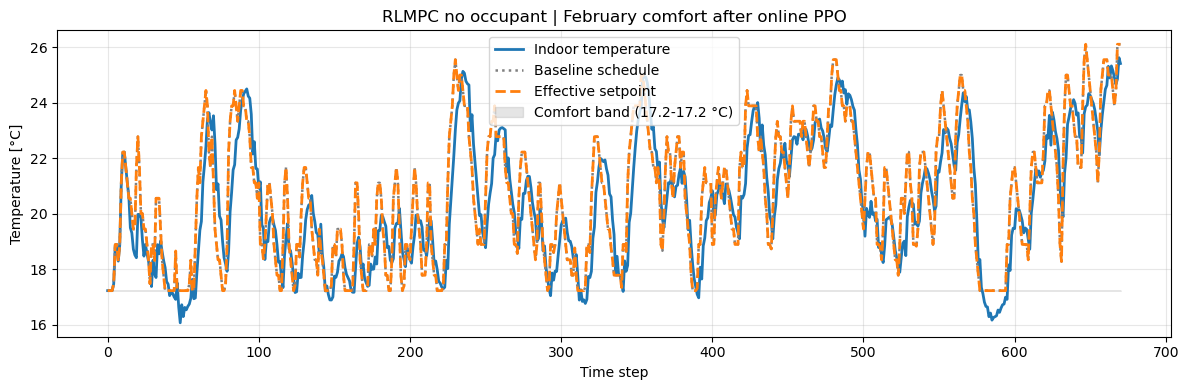

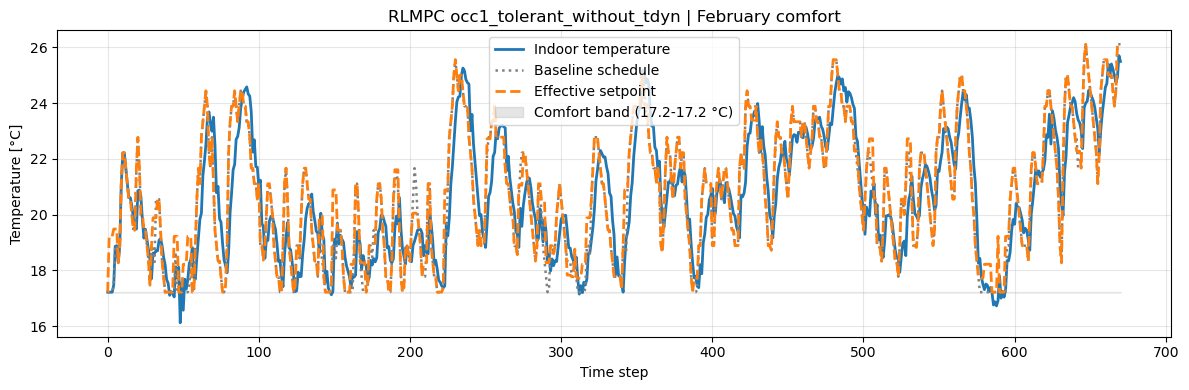

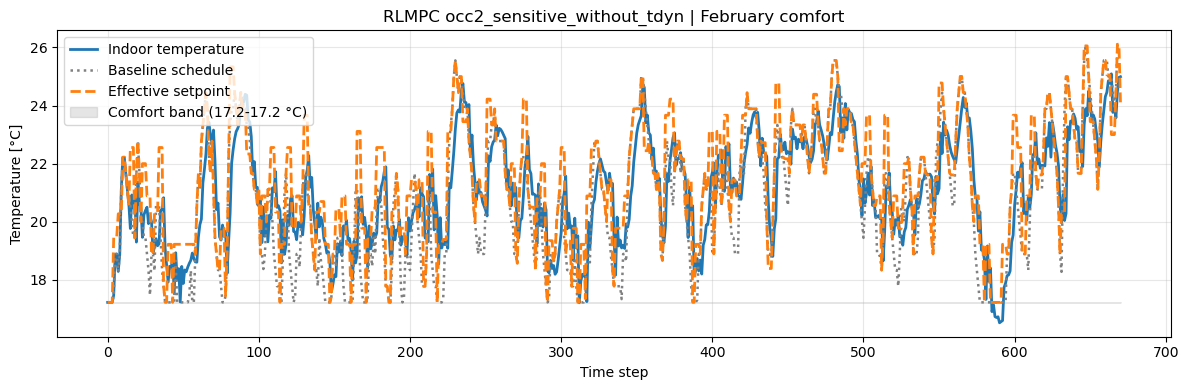

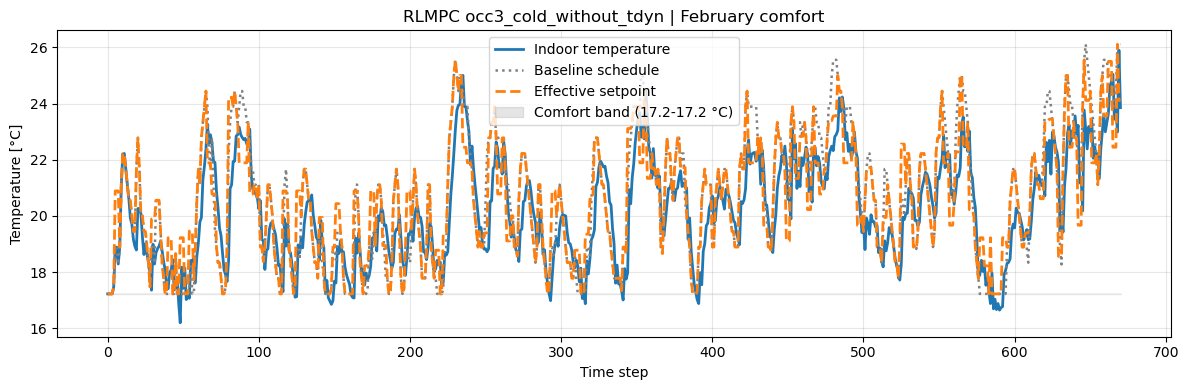

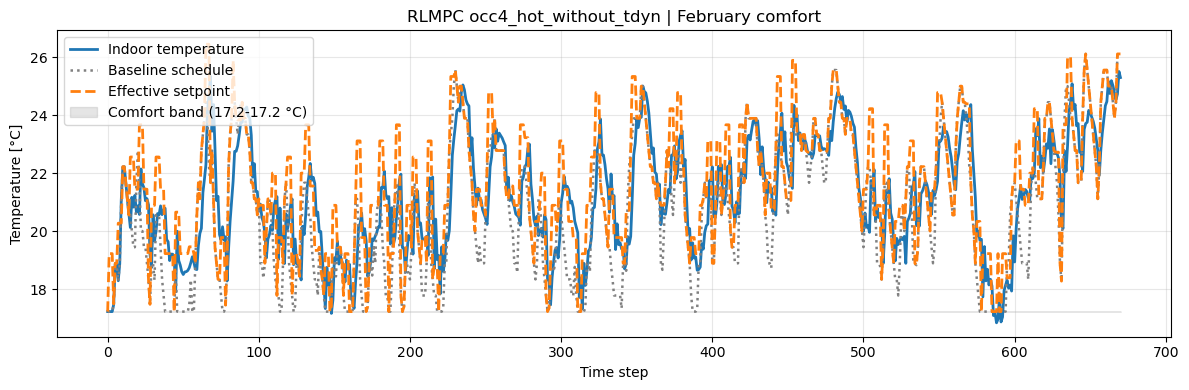

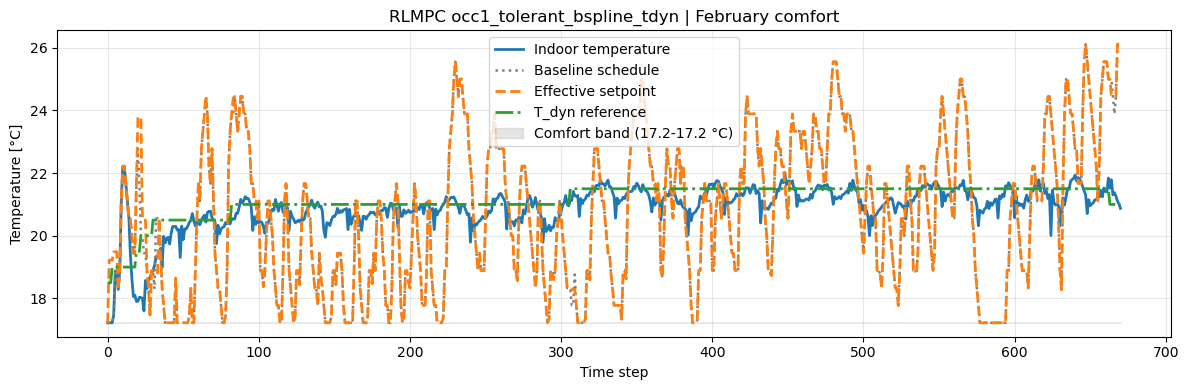

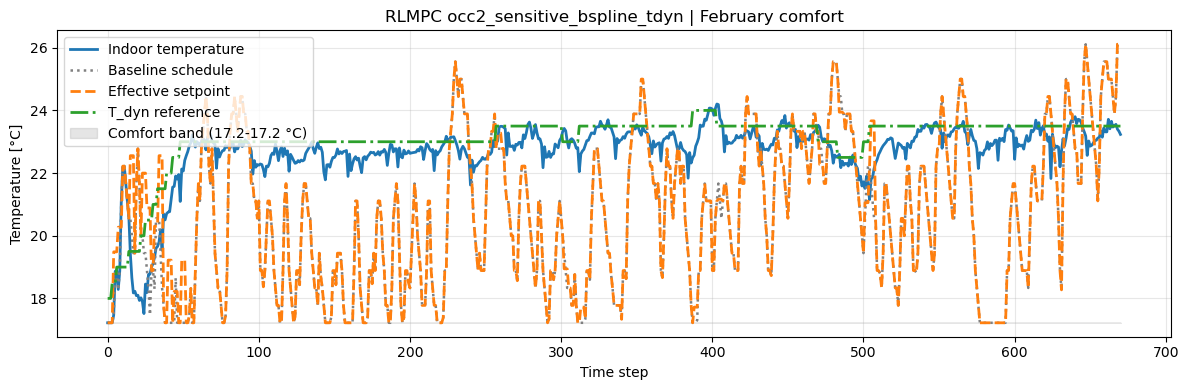

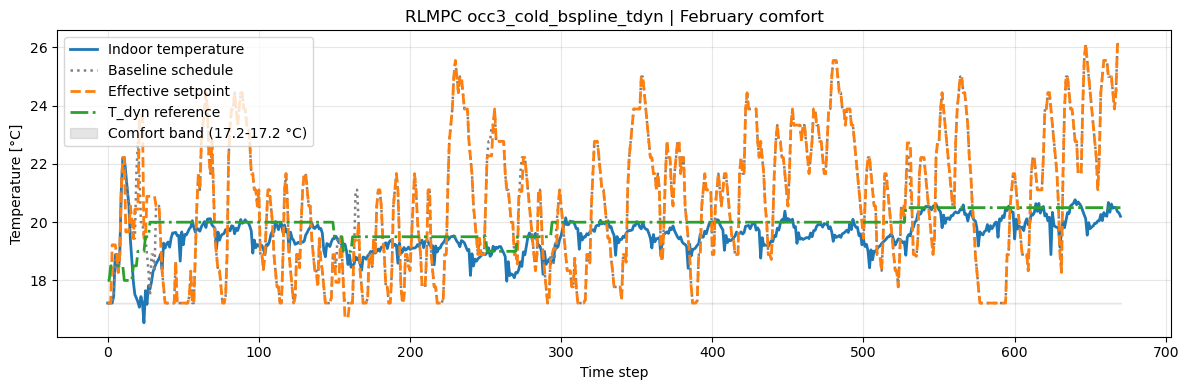

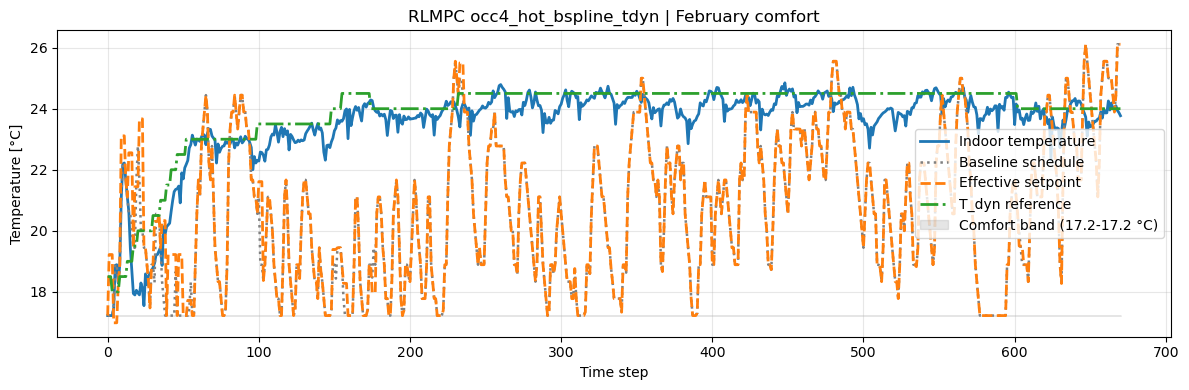

In [9]:
def plot_comfort_from_rollout(history, title='February RLMPC comfort', T_low=None, T_high=None):
    if history.empty:
        print(f'No rollout loaded for: {title}')
        return None

    x = history['time_step'] if 'time_step' in history else range(len(history))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, history['indoor_temperature'], label='Indoor temperature', linewidth=2)

    if 'baseline_setpoint' in history:
        ax.plot(x, history['baseline_setpoint'], ':', label='Baseline schedule', linewidth=1.8, color='gray')
    elif 'tmin' in history:
        ax.plot(x, history['tmin'], ':', label='Heating setpoint', linewidth=1.8, color='gray')

    if 'effective_setpoint' in history:
        ax.plot(x, history['effective_setpoint'], '--', label='Effective setpoint', linewidth=2)

    if 'tdyn' in history:
        ax.plot(x, history['tdyn'], '-.', label='T_dyn reference', linewidth=2)

    if T_low is None:
        T_low = float(history['tmin'].iloc[0]) if 'tmin' in history else 20.0
    if T_high is None:
        T_high = float(history['tmax'].iloc[0]) if 'tmax' in history else 24.0

    ax.fill_between(x, T_low, T_high, color='gray', alpha=0.2, label=f'Comfort band ({T_low:.1f}-{T_high:.1f} °C)')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Temperature [°C]')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return ax

plot_comfort_from_rollout(rlmpc_baseline, title='RLMPC no occupant | February comfort after online PPO')

for label, rollout in rlmpc_rollouts.items():
    if label == 'baseline':
        continue
    plot_comfort_from_rollout(rollout, title=f'RLMPC {label} | February comfort')


## 5. Summary Metrics

/tmp/ipykernel_22933/893807572.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  summary_numeric = summary.apply(pd.to_numeric, errors='ignore')


,case,override_count,reward_total,electricity_consumption_total,discomfort_proportion,discomfort_cold_proportion,discomfort_hot_proportion,daily_peak_average,train_reward_total,train_steps,...,q_track_before,r_u_before,sp_bias_before,q_track_after,r_u_after,sp_bias_after,target_temperature,predicted_occupied_fraction,tdyn_mean,tdyn_final
baseline,baseline,0,-1012.736773,0.991623,0.116031,0.103817,0.012214,1.004855,-33316.123743,671,...,11.69786,0.154399,-0.127999,11.679742,0.153394,-0.102501,NaN,NaN,NaN,NaN
occ1_tolerant_without_tdyn,occ1_tolerant_without_tdyn,36,-963.113503,0.999877,0.102290,0.085496,0.016794,1.006309,-37794.658066,668,...,11.69786,0.154399,-0.127999,11.700013,0.149928,-0.071926,21.861014,NaN,NaN,NaN
occ2_sensitive_without_tdyn,occ2_sensitive_without_tdyn,113,-1456.226817,1.013886,0.233588,0.116031,0.122137,1.010519,-37347.529458,668,...,11.69786,0.154399,-0.127999,11.711766,0.157796,-0.157740,23.035896,NaN,NaN,NaN
occ3_cold_without_tdyn,occ3_cold_without_tdyn,75,-1076.406884,0.972436,0.126718,0.125191,0.001527,0.988944,-37180.845871,668,...,11.69786,0.154399,-0.127999,11.743964,0.155262,-0.145241,19.957358,NaN,NaN,NaN
occ4_hot_without_tdyn,occ4_hot_without_tdyn,113,-1724.997591,1.026471,0.282443,0.128244,0.155725,1.025028,-38147.772969,668,...,11.69786,0.154399,-0.127999,11.720459,0.154779,-0.144221,23.909844,NaN,NaN,NaN
occ1_tolerant_bspline_tdyn,occ1_tolerant_bspline_tdyn,8,-3297.835792,1.015566,0.462595,0.193893,0.268702,1.018377,-37213.034285,668,...,11.69786,0.154399,-0.127999,11.737607,0.151561,-0.092548,21.861014,1.0,21.149776,21.0
occ2_sensitive_bspline_tdyn,occ2_sensitive_bspline_tdyn,19,-6273.921178,1.118978,0.549618,0.053435,0.496183,1.062709,-34929.480863,668,...,11.69786,0.154399,-0.127999,11.715105,0.155271,-0.144122,23.035896,1.0,23.078241,23.5
occ3_cold_bspline_tdyn,occ3_cold_bspline_tdyn,13,-4266.823758,0.942826,0.461069,0.384733,0.076336,0.986308,-36851.046034,668,...,11.69786,0.154399,-0.127999,11.728198,0.154289,-0.150708,19.957358,1.0,19.919523,20.5
occ4_hot_bspline_tdyn,occ4_hot_bspline_tdyn,18,-9212.246702,1.169072,0.644275,0.024427,0.619847,1.087572,-36314.316587,668,...,11.69786,0.154399,-0.127999,11.693914,0.149891,-0.131688,23.909844,1.0,23.883010,24.0


method,with_bspline_tdyn,without_bspline_tdyn
occupant,,
occ1_tolerant,8,36
occ2_sensitive,19,113
occ3_cold,13,75
occ4_hot,18,113


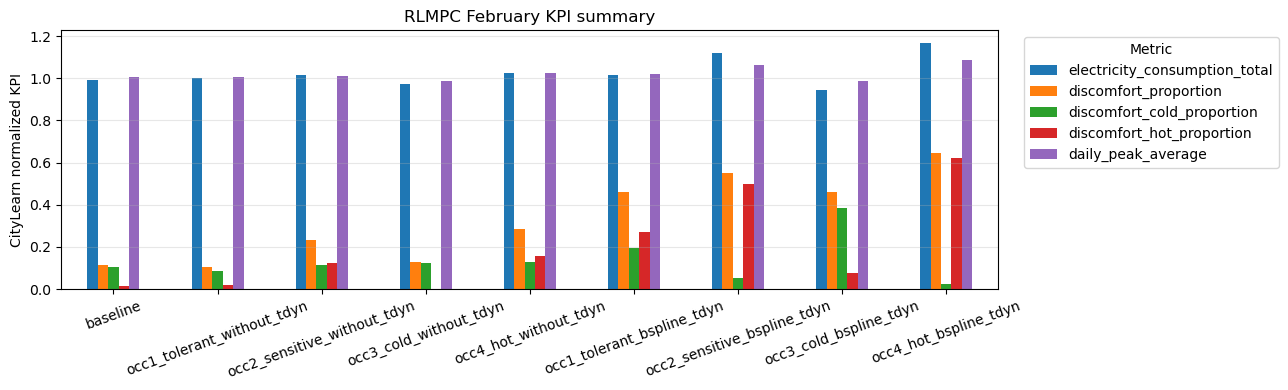

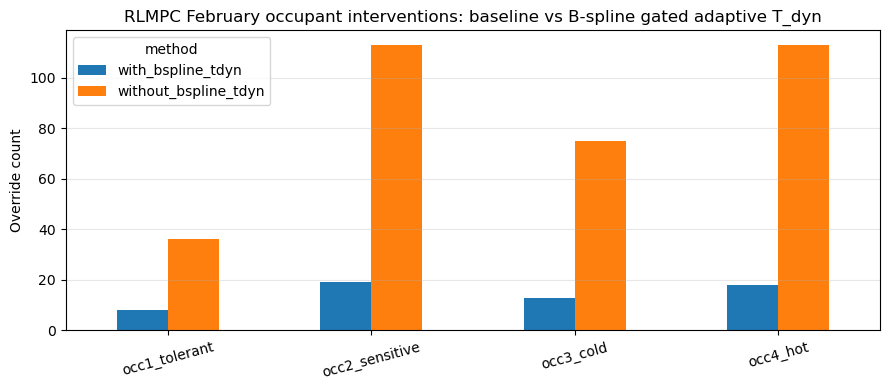

In [10]:
def load_metrics(controller, scenario, case='baseline'):
    candidates = [
        RESULTS / 'summaries' / controller / scenario / f'{case}_metrics.json',
        RESULTS / 'summaries' / controller / scenario / 'metrics.json',
    ]
    for path in candidates:
        if path.exists():
            return json.loads(path.read_text())
    return {}

summary = pd.DataFrame({
    label: load_metrics(CONTROLLER, scenario, case)
    for label, (scenario, case) in RLMPC_CASES.items()
}).T
summary = summary.dropna(how='all')
summary_numeric = summary.apply(pd.to_numeric, errors='ignore')

display(summary_numeric)

if summary_numeric.empty:
    print('No RLMPC metrics available yet. Run scripts/05_run_rlmpc_online.py --scenario no_occupant first.')
else:
    kpi_columns = [
        'electricity_consumption_total',
        'discomfort_proportion',
        'discomfort_cold_proportion',
        'discomfort_hot_proportion',
        'daily_peak_average',
    ]
    plot_data = summary_numeric[[c for c in kpi_columns if c in summary_numeric.columns]].apply(pd.to_numeric, errors='coerce')
    plot_data = plot_data.dropna(axis=1, how='all')

    if plot_data.empty:
        print('No KPI metrics available to plot yet.')
    else:
        ax = plot_data.plot(kind='bar', figsize=(13, 4), rot=20)
        ax.set_xlabel('')
        ax.set_ylabel('CityLearn normalized KPI')
        ax.set_title('RLMPC February KPI summary')
        ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()

    occupant_rows = summary_numeric[summary_numeric.index.to_series().str.contains('tdyn|without_tdyn', regex=True)]
    if not occupant_rows.empty and 'override_count' in occupant_rows:
        method = np.where(occupant_rows.index.str.contains('bspline_tdyn'), 'with_bspline_tdyn', 'without_bspline_tdyn')
        occupant = occupant_rows.index.str.replace('_bspline_tdyn', '', regex=False).str.replace('_without_tdyn', '', regex=False)
        override_compare = occupant_rows.assign(occupant=occupant, method=method).pivot(
            index='occupant',
            columns='method',
            values='override_count',
        )
        display(override_compare)

        ax = override_compare.plot(kind='bar', figsize=(9, 4), rot=15)
        ax.set_xlabel('')
        ax.set_ylabel('Override count')
        ax.set_title('RLMPC February occupant interventions: baseline vs B-spline gated adaptive T_dyn')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
